# 2. MLP Baseline

Here we build a 2-layer MLP that uses **only node features** — no graph structure whatsoever. This establishes our baseline accuracy to compare against the GCN.

Expected test accuracy: ~55–60%

In [1]:
import sys
sys.path.append('../src')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from dataset import load_data

torch.manual_seed(42)
np.random.seed(42)

In [2]:
# Load data — we only use features and labels, NOT the adjacency matrix
adj, features, labels, idx_train, idx_val, idx_test = load_data('../data/cora')
N_FEATURES = features.shape[1]   # 1433
N_CLASSES = int(labels.max().item() + 1)  # 7
print(f'Features: {N_FEATURES}, Classes: {N_CLASSES}')

Loading cora dataset...


Features: 1433, Classes: 7


/home/roshinit-a/Documents/internships/Niser 2026/GNN/gnn-from-scratch/notebooks/../src/dataset.py:125: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  adj = torch.sparse_coo_tensor(indices, values, shape).coalesce()


## Define the MLP

A simple 2-layer Multilayer Perceptron. The `forward` returns both logits and the hidden-layer embeddings (for later t-SNE visualization).

In [3]:
class BaselineMLP(nn.Module):
    """2-layer MLP: Linear -> ReLU -> Dropout -> Linear."""

    def __init__(self, in_features: int, hidden: int, out_features: int, dropout: float = 0.5):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden)   # First linear layer
        self.fc2 = nn.Linear(hidden, out_features)  # Output layer
        self.dropout = dropout

    def forward(self, x):
        h = F.relu(self.fc1(x))                          # Hidden embedding
        h = F.dropout(h, self.dropout, training=self.training)
        logits = self.fc2(h)                             # Class logits
        return logits, h  # Return both for visualization

model_mlp = BaselineMLP(N_FEATURES, 64, N_CLASSES, dropout=0.5)
optimizer = optim.Adam(model_mlp.parameters(), lr=0.01, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()
print(model_mlp)

BaselineMLP(
  (fc1): Linear(in_features=1433, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=7, bias=True)
)


## Training Loop

200 epochs, Adam optimizer with weight decay (same settings as GCN for fair comparison).

In [4]:
train_losses, val_accs = [], []

for epoch in range(200):
    model_mlp.train()
    optimizer.zero_grad()

    logits, _ = model_mlp(features)
    loss = criterion(logits[idx_train], labels[idx_train])
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # Validation
    model_mlp.eval()
    with torch.no_grad():
        val_logits, _ = model_mlp(features)
        val_preds = val_logits[idx_val].argmax(dim=1)
        val_acc = (val_preds == labels[idx_val]).float().mean().item()
        val_accs.append(val_acc)

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d} | Train Loss: {loss.item():.4f} | Val Acc: {val_acc:.4f}')

Epoch  20 | Train Loss: 1.4144 | Val Acc: 0.3680
Epoch  40 | Train Loss: 0.6046 | Val Acc: 0.5540


Epoch  60 | Train Loss: 0.2945 | Val Acc: 0.5880
Epoch  80 | Train Loss: 0.2284 | Val Acc: 0.5920


Epoch 100 | Train Loss: 0.1785 | Val Acc: 0.5920
Epoch 120 | Train Loss: 0.1394 | Val Acc: 0.5920


Epoch 140 | Train Loss: 0.1386 | Val Acc: 0.5880
Epoch 160 | Train Loss: 0.1272 | Val Acc: 0.5900


Epoch 180 | Train Loss: 0.1211 | Val Acc: 0.5920
Epoch 200 | Train Loss: 0.0994 | Val Acc: 0.5860


In [5]:
# Final test accuracy
model_mlp.eval()
with torch.no_grad():
    test_logits, embeddings = model_mlp(features)
    test_preds = test_logits[idx_test].argmax(dim=1)
    test_acc = (test_preds == labels[idx_test]).float().mean().item()

print(f'\nMLP Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)')

# Save for comparison in notebook 03
import json
with open('../results/mlp_acc.json', 'w') as f:
    json.dump({'mlp_test_acc': test_acc}, f)


MLP Test Accuracy: 0.5020 (50.2%)


## Training Curves

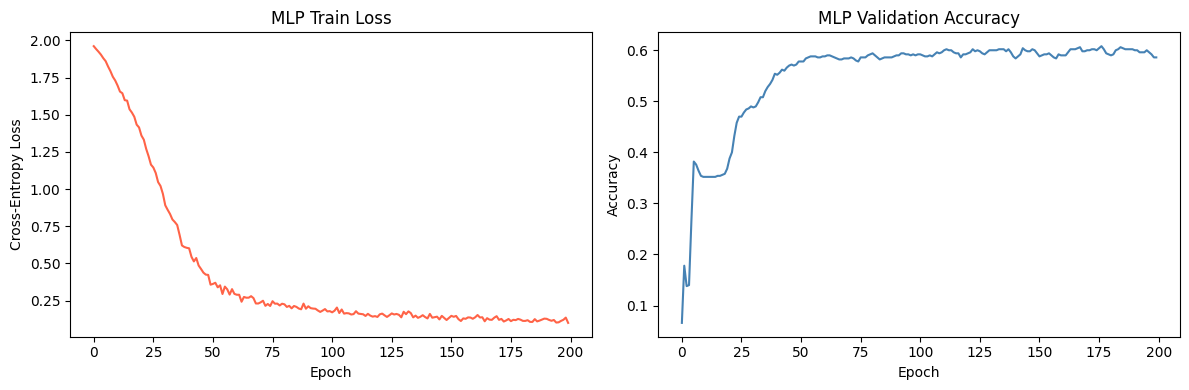

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, color='tomato')
ax1.set_title('MLP Train Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
ax2.plot(val_accs, color='steelblue')
ax2.set_title('MLP Validation Accuracy')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
plt.tight_layout()
plt.savefig('../results/mlp_training_curves.png', dpi=150)
plt.show()

## t-SNE Visualization of MLP Embeddings

We embed ALL 2708 nodes' hidden representations into 2D using t-SNE and color them by class. Without graph structure, the clusters are poorly separated.

Running t-SNE (this may take ~30 seconds)...


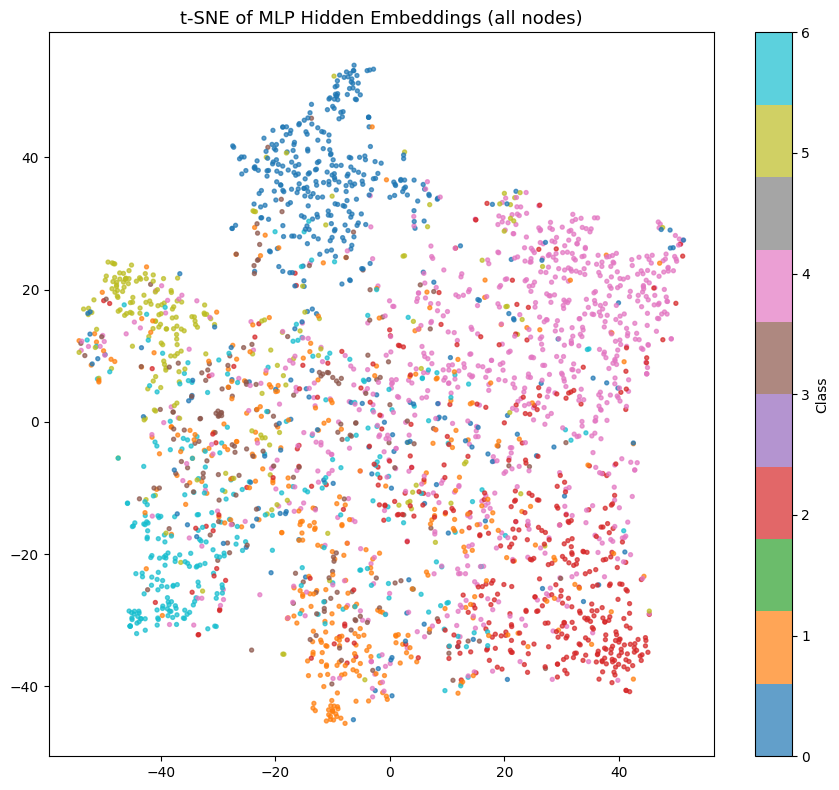

Saved to results/mlp_tsne.png


In [7]:
print('Running t-SNE (this may take ~30 seconds)...')
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb_2d = tsne.fit_transform(embeddings.numpy())

plt.figure(figsize=(9, 8))
scatter = plt.scatter(emb_2d[:, 0], emb_2d[:, 1],
                      c=labels.numpy(), cmap='tab10', alpha=0.7, s=8)
plt.colorbar(scatter, label='Class')
plt.title('t-SNE of MLP Hidden Embeddings (all nodes)', fontsize=13)
plt.tight_layout()
plt.savefig('../results/mlp_tsne.png', dpi=150)
plt.show()
print('Saved to results/mlp_tsne.png')